# 🚀 Practice Day 01

**📅 Date:** 2026-09-12  
**📁 Category:** Phase 1 · Pandas 기초 (Round 1/5)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Explore a single e-commerce orders table from scratch (단일 테이블을 처음부터 탐색)
- Filter and sort rows based on business conditions (조건에 따라 필터링·정렬)
- Use groupby to calculate basic aggregate metrics (groupby로 기본 집계 계산)

---
# 📂 Dataset

**Dataset Name:** Online Shopping Mall Orders (온라인 쇼핑몰 주문 데이터)

**Source:** Synthetically generated for practice, fixed random seed (연습용으로 코드에서 직접 생성, seed 고정)

**Description:** 280 orders from an online shopping mall spanning 6 product categories (Electronics, Clothing, Beauty, Household, Food, Books) and 6 months (Jan–Jun 2026). Includes order date, category, product name, unit price, quantity, and customer region.
(전자제품/의류/뷰티/생활용품/식품/도서 6개 카테고리, 2026년 1~6월 온라인 쇼핑몰 주문 280건. 주문일자·카테고리·상품명·단가·수량·고객 지역 포함)

## Dataset Preview

In [15]:
# Dataset Preview
import pandas as pd
import numpy as np

np.random.seed(42)

n_orders = 280

categories = ['Electronics', 'Clothing', 'Beauty', 'Household', 'Food', 'Books']
category_products = {
    'Electronics': ['Wireless Earbuds', 'Bluetooth Speaker', 'Power Bank', 'Smart Watch', 'USB Hub', 'Laptop Stand'],
    'Clothing': ['Hoodie', 'Jeans', 'Knit Sweater', 'T-Shirt', 'Dress', 'Jacket'],
    'Beauty': ['Skincare Set', 'Lipstick', 'Sunscreen', 'Shampoo', 'Perfume', 'Sheet Mask Pack'],
    'Household': ['Tumbler', 'Kitchen Set', 'Storage Box', 'Air Freshener', 'Cleaning Kit', 'Bedding Set'],
    'Food': ['Coffee Beans', 'Mixed Nuts Set', 'Fruit Gift Set', 'Ramen Box', 'Health Juice', 'Tea Bag Set'],
    'Books': ['Self-Help Book', 'Novel', 'Essay Collection', 'Cookbook', 'Parenting Guide', 'Business Book'],
}
price_ranges = {
    'Electronics': (15000, 150000),
    'Clothing': (15000, 80000),
    'Beauty': (8000, 45000),
    'Household': (5000, 40000),
    'Food': (10000, 50000),
    'Books': (10000, 25000),
}
regions = ['Seoul', 'Gyeonggi', 'Busan', 'Daegu', 'Incheon', 'Gwangju', 'Daejeon', 'Other']
region_weights = [0.30, 0.25, 0.12, 0.08, 0.08, 0.06, 0.06, 0.05]

order_category = np.random.choice(categories, size=n_orders)
product_name = [np.random.choice(category_products[c]) for c in order_category]
price = [int(np.random.randint(*price_ranges[c]) // 100 * 100) for c in order_category]

df = pd.DataFrame({
    'order_id': [f'ORD-{i+1:05d}' for i in range(n_orders)],
    'order_date': np.random.choice(pd.date_range('2026-01-01', '2026-06-30', freq='D'), size=n_orders),
    'category': order_category,
    'product_name': product_name,
    'price': price,
    'quantity': np.random.choice([1, 2, 3, 4, 5], size=n_orders, p=[0.45, 0.30, 0.15, 0.07, 0.03]),
    'customer_region': np.random.choice(regions, size=n_orders, p=region_weights),
})

df['order_date'] = pd.to_datetime(df['order_date'])
df = df.sort_values('order_date').reset_index(drop=True)
df.head()

,order_id,order_date,category,product_name,price,quantity,customer_region
0,ORD-00184,2026-01-01,Books,Self-Help Book,14100,1,Seoul
1,ORD-00007,2026-01-01,Beauty,Sunscreen,19300,1,Seoul
2,ORD-00137,2026-01-01,Clothing,Hoodie,32600,3,Incheon
3,ORD-00030,2026-01-01,Beauty,Sheet Mask Pack,22300,4,Gyeonggi
4,ORD-00147,2026-01-03,Household,Kitchen Set,28900,1,Gyeonggi


## Dataset Information

In [16]:
# Dataset Information
print(df.shape)
df.info()
df.describe(include='all')

(280, 7)
<class 'pandas.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_id         280 non-null    str           
 1   order_date       280 non-null    datetime64[us]
 2   category         280 non-null    str           
 3   product_name     280 non-null    str           
 4   price            280 non-null    int64         
 5   quantity         280 non-null    int64         
 6   customer_region  280 non-null    str           
dtypes: datetime64[us](1), int64(2), str(4)
memory usage: 15.4 KB


,order_id,order_date,category,product_name,price,quantity,customer_region
count,280,280,280,280,280.000000,280.000000,280
unique,280,NaN,6,36,NaN,NaN,8
top,ORD-00184,NaN,Household,Kitchen Set,NaN,NaN,Seoul
freq,1,NaN,59,14,NaN,NaN,91
mean,NaN,2026-03-27 12:36:00,NaN,NaN,38161.071429,1.925000,NaN
min,NaN,2026-01-01 00:00:00,NaN,NaN,5000.000000,1.000000,NaN
25%,NaN,2026-02-08 00:00:00,NaN,NaN,18275.000000,1.000000,NaN
50%,NaN,2026-03-23 00:00:00,NaN,NaN,28800.000000,2.000000,NaN
75%,NaN,2026-05-13 00:00:00,NaN,NaN,44600.000000,2.000000,NaN
max,NaN,2026-06-30 00:00:00,NaN,NaN,147300.000000,5.000000,NaN


---
# ❓ Business Questions

1. Which orders came from customers in Seoul or Gyeonggi with a price of 50,000 KRW or more? (서울/경기 지역 고객의 주문 중 가격이 5만원 이상인 주문은?)
2. What are the top 10 orders by total revenue (price × quantity)? (총 매출(가격×수량) 기준 상위 10개 주문은?)
3. What is the total revenue and average order value for each category? (카테고리별 총 매출과 평균 주문 금액은?)
4. How does total revenue compare across categories? (카테고리별 매출을 비교하면 어떤 모습인가요?)
5. How has monthly revenue trended over the period? (월별 매출은 어떤 추이를 보이나요?)

---
# 🛠 Skills Used
- [x] Python
- [x] NumPy — used to generate the practice dataset with a fixed seed  
  (고정 seed로 연습용 데이터셋을 생성하는 데 사용)
- [x] Pandas — filtering, sorting, groupby, and a derived `revenue` column  
  (필터링·정렬·groupby, 파생 컬럼 `revenue`)
- [x] Matplotlib — bar chart (category revenue) and line chart (monthly trend)  
  (카테고리 매출 막대 차트, 월별 추이 선 차트)

---
# 🔍 Data Cleaning Check

Things I checked:
- [x] Missing Values — 0  
  (결측 없음)
- [x] Duplicate Rows — 0  
  (중복 없음)
- [x] Wrong Data Types — `order_date` is datetime; price and quantity are int  
  (`order_date`는 datetime, 가격·수량은 정수)
- [x] Rename Columns — not needed  
  (변경 불필요)
- [x] Drop Columns — not needed  
  (삭제 불필요)


In [17]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("Missing values")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDtypes")
print(df.dtypes)

print("\nColumn names")
print(df.columns.tolist())

obj_cols = df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(df[obj_cols].nunique())


Missing values
order_id           0
order_date         0
category           0
product_name       0
price              0
quantity           0
customer_region    0
dtype: int64

Duplicate rows: 0

Dtypes
order_id                      str
order_date         datetime64[us]
category                      str
product_name                  str
price                       int64
quantity                    int64
customer_region               str
dtype: object

Column names
['order_id', 'order_date', 'category', 'product_name', 'price', 'quantity', 'customer_region']

Text columns — unique counts
order_id           280
category             6
product_name        36
customer_region      8
dtype: int64


---
# 📊 Analysis

## Question 1

**Question:** Which orders came from customers in Seoul or Gyeonggi with a price of 50,000 KRW or more? (서울/경기 지역 고객의 주문 중 가격이 5만원 이상인 주문은?)

**Result:** 26 orders (9.3% of 280). Only Electronics (16) and Clothing (10) appear — no Beauty, Household, Food, or Books. Seoul 15, Gyeonggi 11.  
(26건, 전체 280건의 9.3%. 카테고리는 전자 16·의류 10뿐이고 뷰티·생활용품·식품·도서는 0건. 서울 15, 경기 11)

**Insight:** High-price orders in the Seoul metro area are not “premium across all categories.” The 50,000 KRW cutoff mainly selects Electronics and Clothing because other categories have lower price ceilings.  
(수도권 고가 주문이 전 카테고리 프리미엄은 아님. 5만 원 필터가 단가 상한이 낮은 카테고리를 거의 걸러 냄)

In [18]:
# Question 1: Filter orders from Seoul/Gyeonggi customers priced >= 50,000 KRW
# (서울/경기 지역 고객의 주문 중 가격이 5만원 이상인 주문 필터링)
df['revenue'] = df['price'] * df['quantity']

customer = df[(df['customer_region'].isin(['Seoul', 'Gyeonggi'])) & (df['price'] >= 50000)]

print(len(customer))
print(customer['category'].value_counts())
print()
print(customer['product_name'].value_counts())
display(customer.sort_values('revenue', ascending=False))


26
category
Electronics    16
Clothing       10
Name: count, dtype: int64

product_name
Laptop Stand         4
Bluetooth Speaker    4
USB Hub              3
Hoodie               3
Power Bank           3
T-Shirt              2
Jacket               2
Dress                2
Smart Watch          1
Wireless Earbuds     1
Jeans                1
Name: count, dtype: int64


,order_id,order_date,category,product_name,price,quantity,customer_region,revenue
77,ORD-00277,2026-02-12,Electronics,Laptop Stand,136400,3,Seoul,409200
188,ORD-00046,2026-04-25,Electronics,Power Bank,141000,2,Seoul,282000
109,ORD-00140,2026-03-05,Electronics,USB Hub,93800,3,Gyeonggi,281400
240,ORD-00223,2026-06-02,Electronics,Laptop Stand,139400,2,Seoul,278800
96,ORD-00188,2026-03-01,Electronics,Bluetooth Speaker,61500,4,Gyeonggi,246000
23,ORD-00065,2026-01-13,Electronics,Smart Watch,118100,2,Gyeonggi,236200
52,ORD-00239,2026-02-02,Clothing,T-Shirt,52400,4,Seoul,209600
197,ORD-00201,2026-05-03,Electronics,Bluetooth Speaker,95600,2,Seoul,191200
276,ORD-00260,2026-06-29,Electronics,Power Bank,88400,2,Seoul,176800
154,ORD-00022,2026-04-04,Electronics,Wireless Earbuds,76400,2,Gyeonggi,152800


## Question 2

**Question:** What are the top 10 orders by total revenue (price × quantity)? (총 매출(가격×수량) 기준 상위 10개 주문은?)

**Result:** All top 10 orders are Electronics. #1 is ORD-00109 (Busan, Wireless Earbuds) at 416,700 KRW. These 10 orders account for about 16% of total revenue (19.94M KRW).  
(상위 10건은 전부 전자제품. 1위는 부산 Wireless Earbuds 416,700원. 상위 10건이 전체 매출 약 1,994만 원의 16%)

**Insight:** Large orders come from a high unit price × 2–4 quantity, not from buying many cheap items. A top-revenue order is not automatically a VIP customer — this table has no customer ID, so repeat purchase cannot be confirmed.  
(큰 주문은 싼 물건을 많이 산 경우가 아니라 고단가 × 2~4개 조합. 매출 상위 주문이 곧 VIP는 아님. 고객 ID가 없어 재구매 여부는 알 수 없음)

In [19]:
# Question 2: Find the top 10 orders by total revenue (price x quantity)
# (총 매출(가격x수량) 기준 상위 10개 주문 찾기)

top_10_revenue = df.sort_values('revenue', ascending=False).head(10)

display(top_10_revenue)


,order_id,order_date,category,product_name,price,quantity,customer_region,revenue
239,ORD-00109,2026-06-01,Electronics,Wireless Earbuds,138900,3,Busan,416700
77,ORD-00277,2026-02-12,Electronics,Laptop Stand,136400,3,Seoul,409200
216,ORD-00122,2026-05-16,Electronics,Bluetooth Speaker,129800,3,Daejeon,389400
42,ORD-00028,2026-01-26,Electronics,Bluetooth Speaker,126800,3,Busan,380400
122,ORD-00094,2026-03-11,Electronics,Power Bank,147300,2,Gwangju,294600
188,ORD-00046,2026-04-25,Electronics,Power Bank,141000,2,Seoul,282000
109,ORD-00140,2026-03-05,Electronics,USB Hub,93800,3,Gyeonggi,281400
161,ORD-00244,2026-04-07,Electronics,Smart Watch,93500,3,Incheon,280500
240,ORD-00223,2026-06-02,Electronics,Laptop Stand,139400,2,Seoul,278800
96,ORD-00188,2026-03-01,Electronics,Bluetooth Speaker,61500,4,Gyeonggi,246000


## Question 3

**Question:** What is the total revenue and average order value for each category? (카테고리별 총 매출과 평균 주문 금액은?)

**Result:** Electronics leads with 7.79M KRW (39% of total), then Clothing 3.69M (19%). Household has the most orders (59) but ranks 3rd in revenue. Books is last at 1.46M (7%). Note: the code used mean unit `price`; true AOV is mean `revenue` (Electronics ~147K vs Books ~34K).  
(전자 779만 원·39%로 1위, 의류 369만 원·19%. 생활용품은 주문 수 최다(59건)지만 매출 3위. 도서가 146만 원·7%로 최하위. 코드의 `price` 평균은 평균 단가이고, 실제 AOV는 `revenue` 평균 — 전자 약 14.7만 원 vs 도서 약 3.4만 원)

**Insight:** Revenue rank ≠ order-count rank. Electronics wins on basket size, not on traffic. Household and Books bring orders but low value per order.  
(매출 순위 ≠ 주문 건수 순위. 전자는 건수가 많아서가 아니라 건당 금액이 커서 1위. 생활용품·도서는 트래픽은 있으나 객단가가 낮음)

In [20]:
# Question 3: Calculate total revenue and average order value per category
# (카테고리별 총 매출과 평균 주문 금액 계산)

categ_rev = (
    df.groupby('category')['revenue']
    .agg(['sum', 'mean'])
    .reset_index()
    .sort_values('sum', ascending=False)
)

display(categ_rev)

,category,sum,mean
3,Electronics,7793300,147043.396226
2,Clothing,3689300,87840.476190
5,Household,2668400,45227.118644
0,Beauty,2219600,48252.173913
4,Food,2109700,57018.918919
1,Books,1458100,33909.302326


---
# 📈 Visualization

**Chart 1:** Total revenue by category (bar chart) — 카테고리별 총 매출 비교

*Interpretation:* Electronics is about 2× Clothing, and the gap vs the other four categories is even wider. The top two categories take ~58% of revenue — sales are concentrated, not evenly spread across six categories.  
(전자가 의류의 약 2배이고, 나머지 4개와의 격차는 더 큼. 상위 2개 카테고리가 매출의 약 58%. 6개 카테고리에 고르게 팔리는 구조가 아님)

---

**Chart 2:** Monthly revenue trend (line chart) — 월별 매출 추이

*Interpretation:* Revenue rises from Jan (2.90M) to a March peak (4.08M), dips in Apr–May, then rebounds in June (3.43M). March also has the most orders (54), so the peak is volume as well as mix. Six months is too short to call this seasonality.  
(1월 290만 → 3월 피크 408만, 4~5월 하락 후 6월 343만으로 반등. 3월은 주문 건수(54건)도 최다라 단가뿐 아니라 거래량 영향. 6개월만으로 계절성이라고 단정하기는 이름)

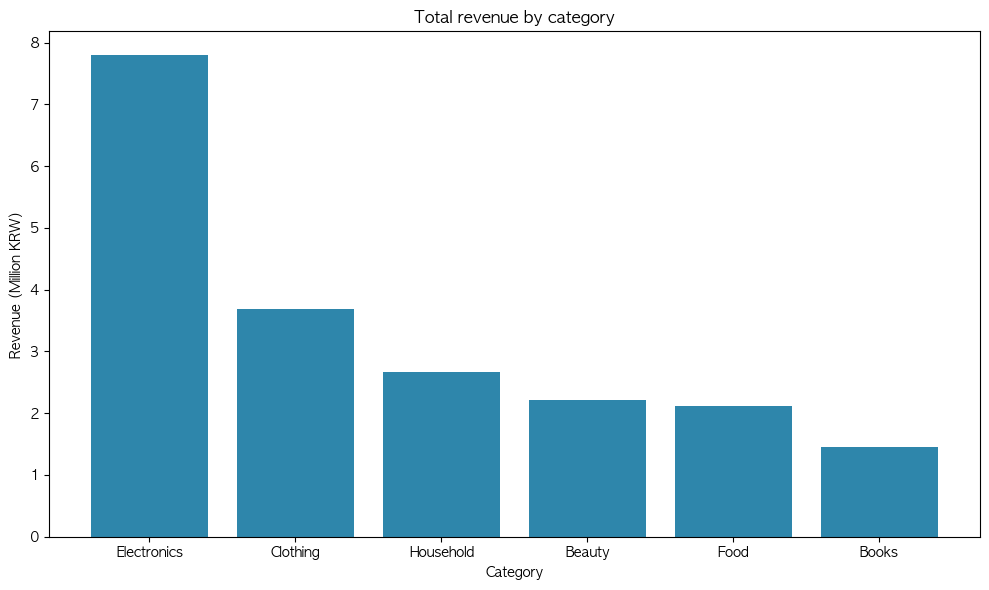

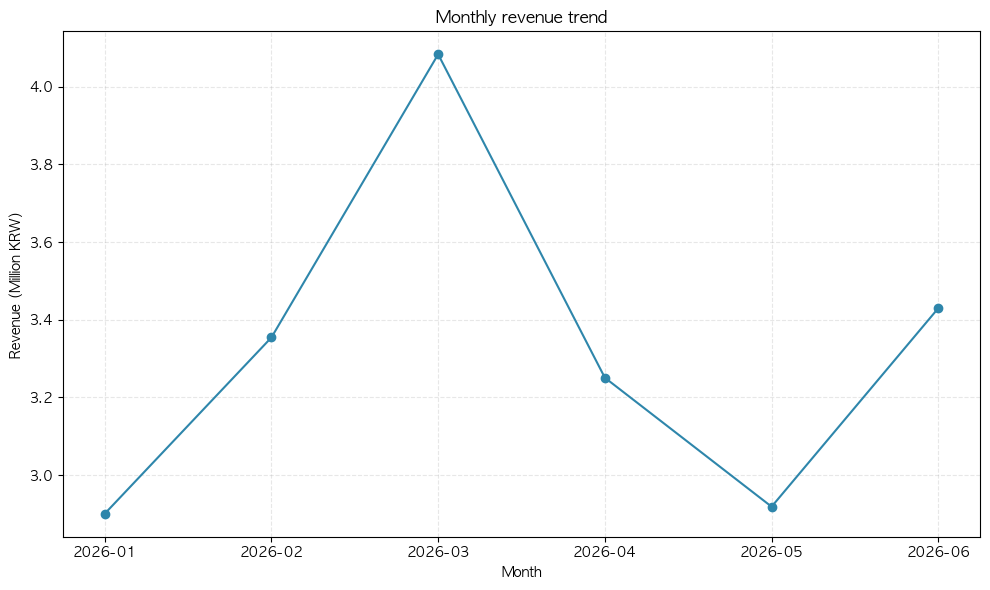

In [21]:
# Visualization
import matplotlib.pyplot as plt
# import seaborn as sns

plt.rcParams['font.family'] = 'AppleGothic'   # macOS: 'AppleGothic', Windows: 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# Chart 1: Total revenue by category (bar chart)
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(categ_rev['category'], categ_rev['sum'] / 1_000_000, color='#2E86AB')
ax.set_title('Total revenue by category')
ax.set_xlabel('Category')
ax.set_ylabel('Revenue (Million KRW)')
plt.tight_layout()
plt.show()

# Chart 2: Monthly revenue trend (line chart)
monthly = df.groupby(df['order_date'].dt.to_period('M'))['revenue'].sum()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(monthly.index.astype(str), monthly.values / 1_000_000, marker='o', color='#2E86AB')
ax.set_title('Monthly revenue trend')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (Million KRW)')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

---
# 💼 Business Insights
*What did I discover?*

- Revenue is concentrated in Electronics (39% of sales; all of the top 10 orders).  
  (매출이 전자제품에 몰려 있음 — 매출의 39%, 상위 10주문도 전부 전자)
- The category with the most orders (Household) is not #1 in revenue. Traffic ≠ sales.  
  (주문이 가장 많은 카테고리(생활용품)가 매출 1위는 아님. 트래픽 ≠ 매출)
- Monthly revenue peaked in March and softened in April–May. This dataset cannot explain why (promo, season, or noise).  
  (월별 매출은 3월이 정점, 4~5월이 꺾임. 프로모션·시즌·우연인지는 이 데이터만으로 알 수 없음) 

---
# 🎯 Business Recommendation
*If I were the Business Analyst...*

1. Prioritize stock and delivery SLA for Electronics — it is the largest revenue contributor.  
   (매출 기여가 가장 큰 전자제품의 재고·배송 SLA를 우선 점검)
2. Treat Household and Books as AOV-lift candidates (bundles), not as categories to defund yet. Traffic is there; basket size is not.  
   (생활용품·도서는 트래픽 대비 객단가가 낮으니 묶음 구매 실험 후보. 지금 바로 예산을 빼자는 근거는 약함)
3. Next analysis: split monthly revenue by category to see whether the March peak / April drop is Electronics-driven or broad.  
   (다음 분석: 월별 매출을 카테고리로 쪼개 3월 피크·4월 하락이 전자 때문인지, 전 카테고리인지 확인) 

---
# ❌ Mistakes
*What mistakes did I make today?*

- Misread Matplotlib’s `1e6` y-axis as literal 0, 1, 2, 3, 4 instead of millions.  
  (y축 `1e6`을 실제 1~4로 읽음)
- Used mean unit `price` for Q3 when the question asked for average order value (`revenue` mean).  
  (Q3에서 AOV 대신 평균 단가를 사용)
- Chart 2 ylabel said “Million KRW” while the plotted values were not divided by 1,000,000.  
  (Chart 2 축 단위는 백만 원인데 값은 나누지 않음) 

---
# ✅ What I Learned
*Today's biggest lesson*

- Aggregate first, then chart. Matplotlib only plots the numbers you already computed.  
  (집계 먼저, 차트는 그 다음. Matplotlib는 이미 만든 숫자를 그릴 뿐)
- `plt.figure()` and `fig, ax = plt.subplots()` are the same library, two styles.  
  (`plt.figure`와 `fig, ax`는 같은 Matplotlib의 다른 문법)
- Result = fact, Insight = meaning. Mixing them makes the write-up hard to use.  
  (Result는 사실, Insight는 의미. 섞으면 보고서로 쓰기 어려움) 

---
# 🧠 Reflection

**What was difficult?**  
Turning code output into Result / Insight / Recommendation, and mapping the learning-notebook `fig, ax` style onto the practice template.  
(코드 결과를 Result·Insight·Recommendation으로 쓰는 것, 학습 노트북의 `fig, ax` 문법을 연습 템플릿에 연결하는 것)

**Why?**  
The analysis cells already printed the answer, so it felt like there was nothing left to say. Visualization syntax also looked different from the study notes.  
(분석 코드가 이미 답을 출력해서 더 쓸 말이 없다고 느낌. 차트 문법도 학습 노트와 달라 보임)

**How did I solve it?**  
Separated fact vs meaning vs action, reused Q3 aggregates for the bar chart, and treated `1e6` as millions.  
(사실·의미·행동을 분리하고, Q3 집계를 막대 차트에 재사용했으며, `1e6`을 백만 단위로 읽음)

**What would I do differently next time?**  
Write Result in one sentence before polishing the chart. Check whether a metric matches the question (AOV vs unit price).  
(차트를 다듬기 전에 Result를 한 문장으로 먼저 적기. 지표가 질문과 맞는지 확인 — AOV vs 단가)


---
# ⭐ Self Evaluation

**Understanding**  
⭐⭐⭐⭐⭐⭐⭐☆☆☆  
Pandas filtering / groupby felt clear; business write-up is still new.  
(필터링·groupby는 이해됨. 비즈니스 문장 쓰기는 아직 익숙하지 않음)

**Confidence**  
⭐⭐⭐⭐⭐⭐☆☆☆☆  
Can produce the tables and charts; less sure about what a stakeholder should do next.  
(표와 차트는 만들 수 있음. 이해관계자에게 다음에 뭘 하라고 말하는 건 아직 덜 확실)

**Difficulty**  
⭐⭐⭐⭐⭐⭐☆☆☆☆  
Day 01 code was manageable; the hard part was interpretation, not syntax.  
(Day 01 코드 난이도는 괜찮았고, 어려운 부분은 문법이 아니라 해석)

---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 02 — NumPy basics (배열 생성, 인덱싱, 집계) 